In [1]:
import polars as pl

pdb_v = pl.read_parquet("../../data/pdb/triad/pdb_validation_triad.conf_af3.parquet")
cresta = pl.read_parquet("../../data/cresta/triad/cresta_triad.conf_af3.parquet")

## Number best specificity class I


In [2]:
part = pdb_v.partition_by(["mhc_1_name", "peptide"])

for phla in part:
    i = 0
    print(phla.select(pl.concat_str("mhc_1_name", "peptide"))[0].item())
    print(phla.filter(~pl.col("cognate")).height)
    phla_srt = phla.sort(by="mean_p_tcr_interface_pae", descending=False)
    for row in phla_srt.iter_rows(named=True):
        if not row["cognate"]:
            break
        else:
            i += 1
    print(i)

A*11:01VVGAVGVGK
20
0
B*57:01TSTLQEQIGW
13
0
A*11:100VVGAVGVGK
10
0
B*35:01LPFDKATIM
12
1
A*02:01LLLDRLNQL
13
1
A*02:01RLQSLQIYV
13
0
A*02:01LLLGIGILVL
12
1
A*02:01NLSALGIFST
12
0
A*24:02NYNYLYRLF
13
0
A*02:01RLQSLQTYV
13
0
B*35:01LPFEKSTIM
12
1
A*02:01EAAGIGILTV
13
0
A*02:01GVYDGREHTV
13
0
B*35:01LPFDKSTIM
12
1


## Summary statistic


In [3]:
print(f"Num CRESTA II: {cresta.filter(pl.col('cognate')).height}")
print(f"Num PDB I: {pdb_v.filter(pl.col('cognate')).height}")
print(f"Num noncog CRESTA II: {cresta.filter(~pl.col('cognate')).height}")
print(f"Num noncog PDB I: {pdb_v.filter(~pl.col('cognate')).height}")

Num CRESTA II: 205
Num PDB I: 16
Num noncog CRESTA II: 1228
Num noncog PDB I: 181


In [4]:
print(f"Num CRESTA II: {cresta.select('mhc_2_name', 'peptide').unique().height}")
print(f"Num PDB I: {pdb_v.select('mhc_1_name', 'peptide').unique().height}")

Num CRESTA II: 8
Num PDB I: 14


In [3]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
import numpy as np
import polars as pl
from sklearn.metrics import auc
import sklearn.metrics as metrics
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from sklearn import metrics
import matplotlib.lines as mlines
import requests

BLAST_URL = "https://blast.ncbi.nlm.nih.gov/blast/Blast.cgi"

RCSB_API = "https://search.rcsb.org/rcsbsearch/v2/query"


def blast_rcsb(seq_id, seq):
    json = {
        "query": {
            "type": "terminal",
            "service": "sequence",
            "parameters": {
                "sequence_type": "protein",
                "value": seq,
                "identity_cutoff": 0.95,
            },
        },
        "request_options": {"paginate": {"start": 0, "rows": 10000}},
        "return_type": "entry",
    }

    r = requests.post(RCSB_API, json=json, timeout=10000)
    r.raise_for_status()

    if r.status_code == 204:
        return pl.DataFrame(
            schema={"pdb": pl.String, "score": pl.Float64, "qseqid": pl.String}
        )

    data_dict = r.json()["result_set"]

    return (
        pl.DataFrame(data_dict)
        .with_columns(pl.lit(seq_id).alias("qseqid"))
        .rename({"identifier": "pdb"})
    )


def antigen_raw_score_summary(
    triad_dataset, featname, grouping_cols=FORMAT_ANTIGEN_COLS, mhc_class="I"
):

    antigens = triad_dataset.select(grouping_cols).unique()

    out_df = []

    for row in antigens.iter_rows(named=True):
        antigen = pl.DataFrame([row]).select(pl.exclude("job_name"))
        aucs = []
        focal_antigen_triads = triad_dataset.join(
            antigen, on=grouping_cols, nulls_equal=True
        )

        new_row = {}

        dat = focal_antigen_triads.select(featname, "cognate").to_numpy()

        fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
        roc_auc = metrics.auc(fpr, tpr)
        new_row["roc_auc"] = roc_auc
        new_row["fpr"] = fpr.tolist()
        new_row["tpr"] = tpr.tolist()
        if mhc_class == "I":
            new_row["name"] = row["mhc_1_name"] + "::" + row["peptide"]
        else:
            new_row["name"] = row["mhc_2_name"] + "::" + row["peptide"]
        out_df.append(new_row)

    summary_row = {}
    dat = triad_dataset.select(featname, "cognate").to_numpy()
    fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
    roc_auc = metrics.auc(fpr, tpr)
    summary_row["roc_auc"] = roc_auc
    summary_row["fpr"] = fpr.tolist()
    summary_row["tpr"] = tpr.tolist()
    summary_row["name"] = "All antigen"

    out_df.append(summary_row)

    return pl.DataFrame(out_df)


def antigen_auc_summary_and_plot(
    triad_dataset: pl.DataFrame,
    featname: str,
    grouping_cols,
    mhc_class: str = "I",
    ax: plt.Axes | None = None,
    title: str | None = None,
    jitter: bool = False,
):
    """
    Computes per-antigen ROC (AUC, AUC@0.1, FPR, TPR) + an 'All antigen' summary,
    and plots ROC curves with small jitter. Legend still shows overall AUC only.
    """
    antigens = triad_dataset.select(grouping_cols).unique()
    rows = []

    for row in antigens.iter_rows(named=True):
        antigen_df = pl.DataFrame([row]).select(pl.exclude("job_name"))
        focal = triad_dataset.join(antigen_df, on=grouping_cols, nulls_equal=True)
        pmhc_in_pdb = focal.filter(pl.col("cognate")).select("pmhc_in_pdb")[0].item()

        dat = focal.select(featname, "cognate").to_numpy()
        y_score = dat[:, 0]
        y_true = dat[:, 1]

        fpr, tpr, _ = metrics.roc_curve(y_true, y_score)
        auc = metrics.auc(fpr, tpr)
        auc_01 = metrics.roc_auc_score(y_true, y_score, max_fpr=0.1)

        name = (
            f"{row['mhc_1_name']}::{row['peptide']}"
            if mhc_class == "I"
            else f"{row['mhc_2_name']}::{row['peptide']}"
        )
        rows.append(
            {
                "name": name,
                "roc_auc": float(auc),
                "roc_auc_0_1": float(auc_01),  # standardized pAUC@0.1
                "fpr": fpr.tolist(),
                "tpr": tpr.tolist(),
                "pmhc_in_pdb": pmhc_in_pdb,
            }
        )

    # # Add overall 'All antigen'
    # dat_all = triad_dataset.select(featname, "cognate").to_numpy()
    # y_score_all = dat_all[:, 0]
    # y_true_all = dat_all[:, 1]
    # fpr_all, tpr_all, _ = metrics.roc_curve(y_true_all, y_score_all)
    # auc_all = metrics.auc(fpr_all, tpr_all)
    # auc_01_all = metrics.roc_auc_score(y_true_all, y_score_all, max_fpr=0.1)

    # rows.append(
    #     {
    #         "name": "All antigen",
    #         "roc_auc": float(auc_all),
    #         "roc_auc_0_1": float(auc_01_all),
    #         "fpr": fpr_all.tolist(),
    #         "tpr": tpr_all.tolist(),
    #     }
    # )

    summary_df = pl.DataFrame(rows)

    # ---------- plotting ----------
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    # def _jitter_curve(fpr, tpr):
    #     dx = rng.uniform(0, 2 * jitter)
    #     dy = rng.uniform(0, 2 * jitter)
    #     fpr_j = np.clip(np.asarray(fpr, float) + dx, 0.0, 1.0)
    #     tpr_j = np.clip(np.asarray(tpr, float) + dy, 0.0, 1.0)
    #     return fpr_j, tpr_j

    # # Plot All antigen first (so it appears first in legend)
    # all_row = summary_df.filter(pl.col("name") == "All antigen").row(0, named=True)
    # fpr_j, tpr_j = _jitter_curve(all_row["fpr"], all_row["tpr"])
    # ax.plot(
    #     fpr_j,
    #     tpr_j,
    #     lw=2.5,
    #     color="black",
    #     label=f"{all_row['name']} (AUC {all_row['roc_auc']:.2f}) (AUC@0.1 {all_row['roc_auc_0_1']:.2f})",
    #     zorder=3,
    # )

    plot_handles = []
    i = 0

    # Plot other antigens
    for row in (
        summary_df.filter(pl.col("name") != "All antigen")
        .sort(by="roc_auc", descending=True)
        .iter_rows(named=True)
    ):
        # fpr_j, tpr_j = _jitter_curve(row["fpr"], row["tpr"])
        fpr_j = np.asarray(row["fpr"]) + i
        tpr_j = np.asarray(row["tpr"]) + i
        if jitter:
            i += 0.004
        lab = f"{row['name']}(*)" if not row["pmhc_in_pdb"] else f"{row['name']}"

        if row["pmhc_in_pdb"]:
            linestyle = "-"
        else:
            linestyle = "-"

        (line_handle,) = ax.plot(fpr_j, tpr_j, lw=1, label=lab, linestyle=linestyle)

        plot_handles.append(line_handle)

    ax.plot([0, 1], [0, 1], "--", lw=1, color="grey")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    med = summary_df.select(pl.col("roc_auc").median()).item()

    min_auc = summary_df.select(pl.col("roc_auc").min()).item()
    max_auc = summary_df.select(pl.col("roc_auc").max()).item()
    # note = mlines.Line2D(
    #     [],
    #     [],
    #     linestyle="none",
    #     label=f"Median AUC {med:.2f} (range={min_auc:.2f}-{max_auc:.2f})",
    #     c="black",
    # )

    note2 = mlines.Line2D(
        [],
        [],
        linestyle="none",
        label="(*)=no antigen overlap with pre-training PDB",
        c="black",
    )
    # ax.text(
    #     0.7,
    #     0.2,
    #     f"Median AUC {med:.2f} (range={min_auc:.2f}-{max_auc:.2f})",
    #     transform=ax.transAxes,
    #     ha="center",
    #     va="bottom",
    #     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5),
    # )

    if title:
        title += f"\nMedian AUC {med:.2f} (range={min_auc:.2f}-{max_auc:.2f})"
        ax.set_title(title)

    ax.legend(handles=[note2] + plot_handles, loc="lower right", fontsize=6)
    ax.grid(True)
    plt.grid(False)

    return summary_df, ax

roc_auc
f64
0.884615


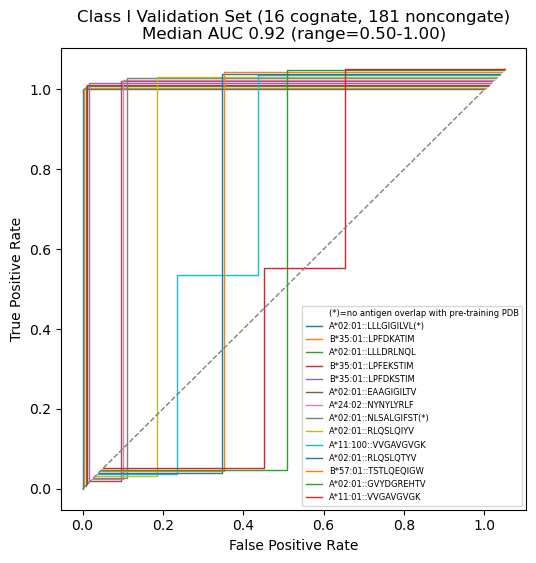

In [4]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen
from sklearn import metrics

auc_df, ax = antigen_auc_summary_and_plot(
    pdb_v.with_columns(
        (31 - pl.col("mean_p_tcr_interface_pae")).alias("mean_p_tcr_interface_pae")
    ),
    "mean_p_tcr_interface_pae",
    grouping_cols=["peptide", "mhc_1_name"],
    mhc_class="I",
    jitter=True,
    title=f"Class I Validation Set ({pdb_v.filter(pl.col('cognate')).height} cognate, {pdb_v.filter(~pl.col('cognate')).height} noncongate)",
)

auc_df.filter(~pl.col("pmhc_in_pdb"))
auc_df.filter(pl.col("pmhc_in_pdb")).select(pl.col("roc_auc").median())
# ax = plot_auc_per_antigen(auc_df, id_cols=["name"])

In [9]:
auc_df.filter(pl.col("roc_auc") == 1)

name,roc_auc,roc_auc_0_1,fpr,tpr
str,f64,f64,list[f64],list[f64]
"""A*02:01::LLLGIGILVL""",1.0,1.0,"[0.0, 0.0, 1.0]","[0.0, 1.0, 1.0]"
"""A*02:01::LLLDRLNQL""",1.0,1.0,"[0.0, 0.0, 1.0]","[0.0, 1.0, 1.0]"
"""B*35:01::LPFDKSTIM""",1.0,1.0,"[0.0, 0.0, 1.0]","[0.0, 1.0, 1.0]"
"""B*35:01::LPFEKSTIM""",1.0,1.0,"[0.0, 0.0, 1.0]","[0.0, 1.0, 1.0]"
"""B*35:01::LPFDKATIM""",1.0,1.0,"[0.0, 0.0, 1.0]","[0.0, 1.0, 1.0]"


In [7]:
auc_df[0].filter(pl.col("name") != "All antigen").select(pl.col("roc_auc").median())

roc_auc
f64
0.919872


In [6]:
auc_df.filter(~pl.col("pmhc_in_pdb"))

name,roc_auc,roc_auc_0_1,fpr,tpr,pmhc_in_pdb
str,f64,f64,list[f64],list[f64],bool
"""A*02:01::LLLGIGILVL""",1.0,1.0,"[0.0, 0.0, 1.0]","[0.0, 1.0, 1.0]",false
"""A*02:01::NLSALGIFST""",0.916667,0.561404,"[0.0, 0.083333, … 1.0]","[0.0, 0.0, … 1.0]",false


In [22]:
t1, t2, pdb = list(
    pdb_v.filter(pl.col("peptide") == "LLLGIGILVL", pl.col("cognate"))
    .select("tcr_1_seq", "tcr_2_seq", "pdb")
    .iter_rows()
)[0]

print(pdb)
print(t1)
print(t2)

t1_res = blast_rcsb(t1, t1)
t2_res = blast_rcsb(t2, t2)

t1_res.join(t2_res, on="pdb")

7q9a
QEVEQNSGPLSVPEGAIASLNCTYSDRGSQSFFWYRQYSGKSPELIMFIYSNGDKEDGRFTAQLNKASQYVSLLIRDSQPSDSATYLCAVNVAGKSTFGDGTTLTVKPNIQNPDPAVYQLRDSKSSDKSVCLFTDFDSQTNVSQSKDSDVYITDKCVLDMRSMDFKSNSAVAWSNKSDFACANAFNNSIIPEDTFFPSP
SQTIHQWPATLVQPVGSPLSLECTVEGTSNPNLYWYRQAAGRGLQLLFYSVGIGQISSEVPQNLSASRPQDRQFILSSKKLLLSDSGFYLCAWSETGLGTGELFFGEGSRLTVLEDLKNVFPPEVAVFEPSEAEISHTQKATLVCLATGFYPDHVELSWWVNGKEVHSGVCTDPQPLKEQPALNDSRYALSSRLRVSATFWQDPRNHFRCQVQFYGLSENDEWTQDRAKPVTQIVSAEAWGRAD


pdb,score,qseqid,score_right,qseqid_right
str,f64,str,f64,str
"""3HG1""",0.947368,"""QEVEQNSGPLSVPEGAIASLNCTYSDRGSQ…",1.0,"""SQTIHQWPATLVQPVGSPLSLECTVEGTSN…"
"""4QOK""",0.947368,"""QEVEQNSGPLSVPEGAIASLNCTYSDRGSQ…",1.0,"""SQTIHQWPATLVQPVGSPLSLECTVEGTSN…"
"""6EQA""",0.947368,"""QEVEQNSGPLSVPEGAIASLNCTYSDRGSQ…",1.0,"""SQTIHQWPATLVQPVGSPLSLECTVEGTSN…"
"""7Q99""",0.991228,"""QEVEQNSGPLSVPEGAIASLNCTYSDRGSQ…",1.0,"""SQTIHQWPATLVQPVGSPLSLECTVEGTSN…"
"""7Q9A""",1.0,"""QEVEQNSGPLSVPEGAIASLNCTYSDRGSQ…",1.0,"""SQTIHQWPATLVQPVGSPLSLECTVEGTSN…"
"""6U07""",0.0,"""QEVEQNSGPLSVPEGAIASLNCTYSDRGSQ…",0.0,"""SQTIHQWPATLVQPVGSPLSLECTVEGTSN…"


In [ ]:
t1, t2, pdb = list(
    pdb_v.filter(pl.col("peptide") == "NLSALGIFST", pl.col("cognate"))
    .select("tcr_1_seq", "tcr_2_seq", "pdb")
    .iter_rows()
)[0]

print(pdb)
print(t1)
print(t2)

t1_res = blast_rcsb(t1, t1)
t2_res = blast_rcsb(t2, t2)

t1_res.join(t2_res, on="pdb").select("qseqid")[-1].item()

7q99
EVEQNSGPLSVPEGAIASLNCTYSDRGSQSFFWYRQYSGKSPELIMFIYSNGDKEDGRFTAQLNKASQYVSLLIRDSQPSDSATYLCAVNVAGKSTFGDGTTLTVKPNIQNPDPAVYQLRDSKSSDKSVCLFTDFDSQTNVSQSKDSDVYITDKCVLDMRSMDFKSNSAVAWSNKSDFACANAFNNSIIPEDTFFPSP
SQTIHQWPATLVQPVGSPLSLECTVEGTSNPNLYWYRQAAGRGLQLLFYSVGIGQISSEVPQNLSASRPQDRQFILSSKKLLLSDSGFYLCAWSETGLGTGELFFGEGSRLTVLEDLKNVFPPEVAVFEPSEAEISHTQKATLVCLATGFYPDHVELSWWVNGKEVHSGVCTDPQPLKEQPALNDSRYALSSRLRVSATFWQDPRNHFRCQVQFYGLSENDEWTQDRAKPVTQIVSAEAWGRAD


'EVEQNSGPLSVPEGAIASLNCTYSDRGSQSFFWYRQYSGKSPELIMFIYSNGDKEDGRFTAQLNKASQYVSLLIRDSQPSDSATYLCAVNVAGKSTFGDGTTLTVKPNIQNPDPAVYQLRDSKSSDKSVCLFTDFDSQTNVSQSKDSDVYITDKCVLDMRSMDFKSNSAVAWSNKSDFACANAFNNSIIPEDTFFPSP'

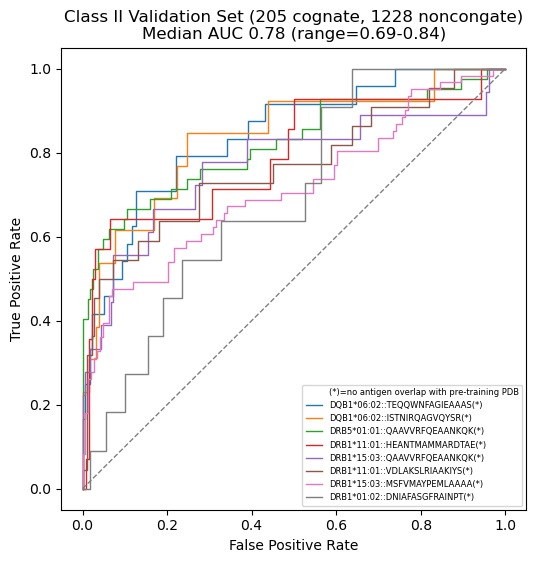

In [5]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen
from sklearn import metrics

auc_df, ax = antigen_auc_summary_and_plot(
    cresta.with_columns(
        (31 - pl.col("mean_p_tcr_interface_pae")).alias("mean_p_tcr_interface_pae")
    ),
    "mean_p_tcr_interface_pae",
    grouping_cols=["peptide", "mhc_2_name"],
    mhc_class="II",
    jitter=False,
    title=f"Class II Validation Set ({cresta.filter(pl.col('cognate')).height} cognate, {cresta.filter(~pl.col('cognate')).height} noncongate)",
)


# ax = plot_auc_per_antigen(auc_df, id_cols=["name"])

In [10]:
auc_df

name,roc_auc,roc_auc_0_1,fpr,tpr,pmhc_in_pdb
str,f64,f64,list[f64],list[f64],bool
"""DRB1*11:01::VDLAKSLRIAAKIYS""",0.764985,0.7003,"[0.0, 0.0, … 1.0]","[0.0, 0.045455, … 1.0]",false
"""DRB1*15:03::MSFVMAYPEMLAAAA""",0.713631,0.66115,"[0.0, 0.0, … 1.0]","[0.0, 0.016393, … 1.0]",false
"""DRB1*01:02::DNIAFASGFRAINPT""",0.693388,0.53458,"[0.0, 0.009091, … 1.0]","[0.0, 0.0, … 1.0]",false
"""DQB1*06:02::ISTNIRQAGVQYSR""",0.83787,0.716599,"[0.0, 0.0, … 1.0]","[0.0, 0.076923, … 1.0]",false
"""DRB1*15:03::QAAVVRFQEAANKQK""",0.771605,0.68486,"[0.0, 0.0, … 1.0]","[0.0, 0.055556, … 1.0]",false
"""DRB5*01:01::QAAVVRFQEAANKQK""",0.821723,0.764844,"[0.0, 0.0, … 1.0]","[0.0, 0.02381, … 1.0]",false
"""DRB1*11:01::HEANTMAMMARDTAE""",0.794388,0.736842,"[0.0, 0.007143, … 1.0]","[0.0, 0.0, … 1.0]",false
"""DQB1*06:02::TEQQWNFAGIEAAAS""",0.842772,0.692134,"[0.0, 0.0, … 1.0]","[0.0, 0.041667, … 1.0]",false


In [5]:
auc_df.with_columns(
    (pl.col("fpr").list.eval((pl.element() != 0).arg_true()).list.get(0) - 1).alias(
        "first_nonzero"
    )
).with_columns(pl.col("tpr").list.get(pl.col("first_nonzero")).alias("tpr@fpr=0")).sort(
    by="tpr@fpr=0"
).select(
    "tpr@fpr=0"
).median()

tpr@fpr=0
f64
0.124317


In [10]:
auc_df.with_columns(
    (pl.col("fpr").list.eval((pl.element() > 0.5).arg_true()).list.get(0) - 1).alias(
        "first_below50"
    )
).with_columns(
    pl.col("tpr").list.get(pl.col("first_below50")).alias("tpr@fpr=0.5")
).sort(
    by="tpr@fpr=0.5"
).select(
    "tpr@fpr=0.5"
).median()

tpr@fpr=0.5
f64
0.833333


In [9]:
auc_df[0].filter(pl.col("name") != "All antigen").select(pl.col("roc_auc").median())

roc_auc
f64
0.775589


## PMHC in PDB subset


In [10]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS

known_pmhc = pdb_v.filter(pl.col("pmhc_in_pdb")).select(FORMAT_ANTIGEN_COLS).unique()

pdb_v_in = pdb_v.join(known_pmhc, on=FORMAT_ANTIGEN_COLS, how="inner")
pdb_v_out = pdb_v.join(known_pmhc, on=FORMAT_ANTIGEN_COLS, how="anti")

known_pmhc = cresta.filter(pl.col("pmhc_in_pdb")).select(FORMAT_ANTIGEN_COLS).unique()
cresta_in = cresta.join(known_pmhc, on=FORMAT_ANTIGEN_COLS, how="inner")
cresta_out = cresta.join(known_pmhc, on=FORMAT_ANTIGEN_COLS, how="anti")

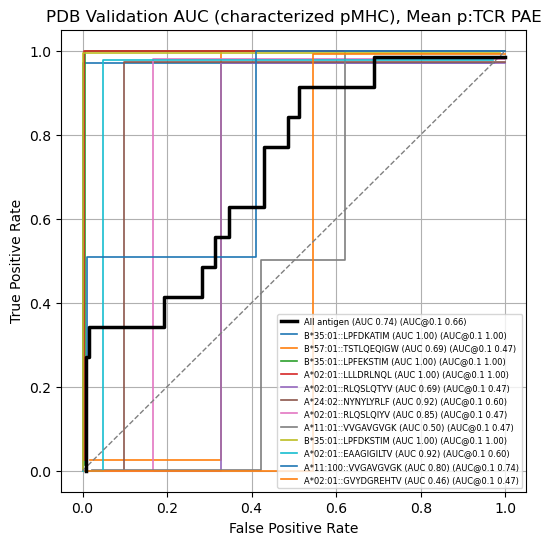

In [16]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen
from sklearn import metrics

auc_df = antigen_auc_summary_and_plot(
    pdb_v_in.with_columns((31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
    grouping_cols=["peptide", "mhc_1_name"],
    mhc_class="I",
    jitter=0.03,
    title="PDB Validation AUC (characterized pMHC), Mean p:TCR PAE",
)

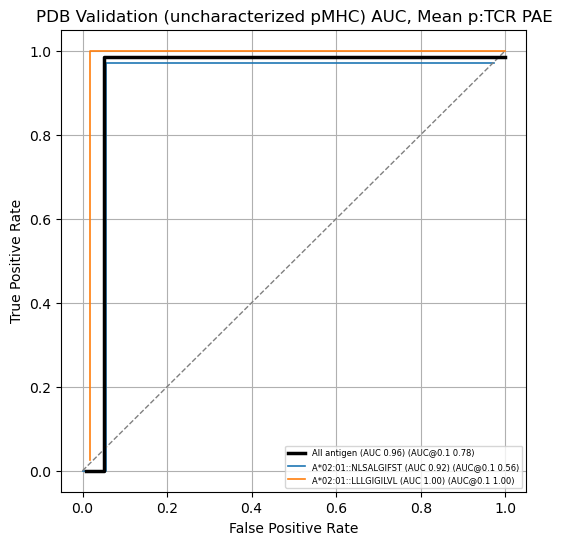

In [15]:
auc_df = antigen_auc_summary_and_plot(
    pdb_v_out.with_columns((31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
    grouping_cols=["peptide", "mhc_1_name"],
    mhc_class="I",
    jitter=0.03,
    title="PDB Validation (uncharacterized pMHC) AUC, Mean p:TCR PAE",
)